# 03 — Priprema podataka za modelovanje

Ucitavam ocisceni dataset iz notebook 01, radim log-transformaciju, encodujem kategoricke varijable,
delim na train/val/test i skaliram features. Na kraju cuvam sve sto mi treba za trening.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/exoplanet_cleaned.csv")
print(f"Ucitano: {df.shape[0]} redova × {df.shape[1]} kolona")

Ucitano: 2349 redova × 25 kolona


## 1. Log-transformacija

Masa, radijus, orbitalni period i poluosa pokrivaju vise redova velicine.
Log-transformacija linearizuje odnose i pomaze linearnim modelima.

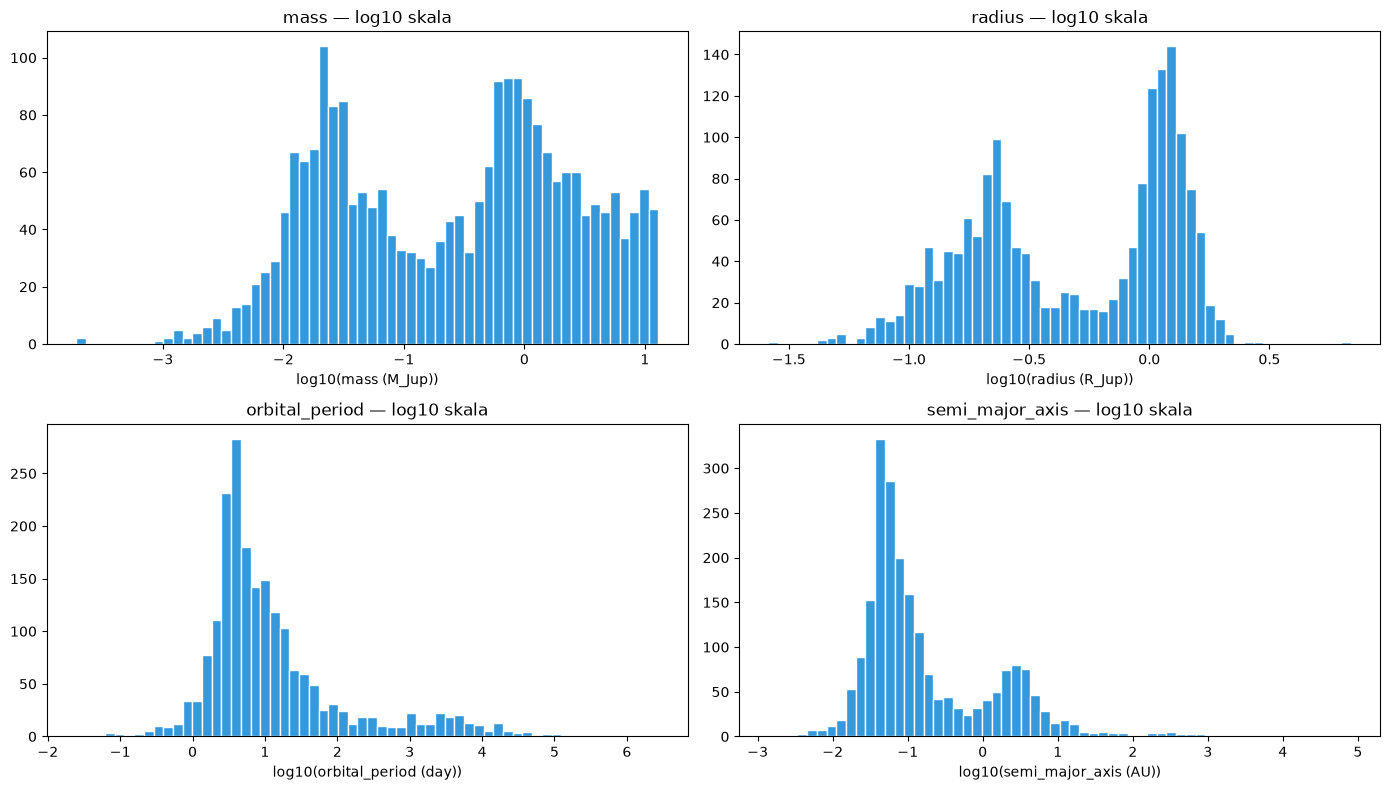

In [2]:
df["log_mass"] = np.log10(df["mass"])
df["log_radius"] = np.log10(df["radius"])
df["log_period"] = np.log10(df["orbital_period"])
df["log_semi_major_axis"] = np.log10(df["semi_major_axis"])

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col, log_col, label in zip(
    axes.flat,
    ["mass", "radius", "orbital_period", "semi_major_axis"],
    ["log_mass", "log_radius", "log_period", "log_semi_major_axis"],
    ["mass (M_Jup)", "radius (R_Jup)", "orbital_period (day)", "semi_major_axis (AU)"],
):
    ax.hist(df[log_col].dropna(), bins=60, color="#3498db", edgecolor="white")
    ax.set_title(f"{col} — log10 skala")
    ax.set_xlabel(f"log10({label})")

plt.tight_layout()
plt.show()

## 1b. Feature engineering

Kreiramo nove feature-e iz postojecih kolona na osnovu fizickih zakona.
Nijedan ne koristi masu planete, tako da nema data leakage-a.

In [3]:
# Stefan-Boltzmann: luminoznost zvezde u L_Sun
df["star_luminosity"] = (df["star_radius"]) ** 2 * (df["star_teff"] / 5778) ** 4

# Gustina zvezde (proporcionalno)
df["star_density"] = df["star_mass"] / df["star_radius"] ** 3

# Primljeno zracenje (insolation flux, proporcionalno)
df["insolation"] = (df["star_teff"] / 5778) ** 4 * (df["star_radius"] / df["semi_major_axis"]) ** 2

# Keplerov 3. zakon: a^3 / P^2 ≈ M_star
df["kepler_ratio"] = df["semi_major_axis"] ** 3 / df["orbital_period"] ** 2

# Relativna udaljenost orbite u odnosu na velicinu zvezde
df["relative_orbit"] = df["semi_major_axis"] / df["star_radius"]

# Ravnotezna temperatura planete (energetski balans)
R_sun_au = 0.00465047  # R_Sun u AU
df["equilibrium_temp"] = df["star_teff"] * np.sqrt(df["star_radius"] * R_sun_au / (2 * df["semi_major_axis"]))

# Orbitalna brzina planete (AU/dan)
df["orbital_velocity"] = 2 * np.pi * df["semi_major_axis"] / df["orbital_period"]

# Transit depth: odnos povrsina planete i zvezde
df["transit_depth"] = (df["radius"] / df["star_radius"]) ** 2

# Plimski uticaj zvezde (proporcionalno)
df["tidal_force"] = df["star_mass"] / df["semi_major_axis"] ** 3

# Pozicija relativno prema nastanjivoj zoni
df["habitable_zone_ratio"] = df["semi_major_axis"] / np.sqrt(df["star_luminosity"])

# Specificna orbitalna energija (vis-viva, proporcionalno)
df["specific_orbital_energy"] = df["star_mass"] / (2 * df["semi_major_axis"])

# Odnos radijusa planete i zvezde
df["planet_star_radius_ratio"] = df["radius"] / df["star_radius"]

engineered_cols = [
    "log_period", "log_semi_major_axis", "star_luminosity", "star_density",
    "insolation", "kepler_ratio", "relative_orbit", "equilibrium_temp",
    "orbital_velocity", "transit_depth", "tidal_force", "habitable_zone_ratio",
    "specific_orbital_energy", "planet_star_radius_ratio",
]

print(f"Kreirano {len(engineered_cols)} novih feature-a:")
for col in engineered_cols:
    n = df[col].notna().sum()
    print(f"  {col:30s}  {n}/{len(df)} ({n/len(df)*100:.1f}%)")

Kreirano 14 novih feature-a:
  log_period                      2006/2349 (85.4%)
  log_semi_major_axis             2182/2349 (92.9%)
  star_luminosity                 1917/2349 (81.6%)
  star_density                    1926/2349 (82.0%)
  insolation                      1773/2349 (75.5%)
  kepler_ratio                    1850/2349 (78.8%)
  relative_orbit                  1793/2349 (76.3%)
  equilibrium_temp                1773/2349 (75.5%)
  orbital_velocity                1850/2349 (78.8%)
  transit_depth                   1691/2349 (72.0%)
  tidal_force                     2107/2349 (89.7%)
  habitable_zone_ratio            1773/2349 (75.5%)
  specific_orbital_energy         2107/2349 (89.7%)
  planet_star_radius_ratio        1691/2349 (72.0%)


## 2. Izbor features-a

Na osnovu EDA i korelacione analize, biram finalni set features-a:
- Originalne numericke kolone (iz cleaned dataseta)
- Novi inzenjerisani feature-i (iz koraka 1b)
- `detection_type` kao kategoricki feature

`name` je identifikator, `mass` / `log_mass` su target — ne idu u features.
`star_sp_type` ima previse unikatnih vrednosti — izbacujem ga.

In [4]:
numericke_features = [
    # Originalne kolone
    "log_radius",
    "orbital_period",
    "semi_major_axis",
    "eccentricity",
    "star_mass",
    "star_radius",
    "star_teff",
    "star_metallicity",
    # Dodatne raw kolone
    "star_distance",
    "mag_v",
    "inclination",
    "star_age",
    "impact_parameter",
    "temp_calculated",
    # Inzenjerisani feature-i
    "log_period",
    "log_semi_major_axis",
    "star_luminosity",
    "star_density",
    "insolation",
    "kepler_ratio",
    "relative_orbit",
    "equilibrium_temp",
    "orbital_velocity",
    "transit_depth",
    "tidal_force",
    "habitable_zone_ratio",
    "specific_orbital_energy",
    "planet_star_radius_ratio",
]

kategoricke_features = ["detection_type"]

target = "log_mass"

# Izbacujem redove gde je radius NaN jer je log_radius najbitniji feature
df_model = df.dropna(subset=["log_radius"]).copy()
print(f"Posle izbacivanja redova bez radijusa: {len(df_model)} redova (bilo {len(df)})")

# Provera da li sve kolone postoje
missing_cols = [c for c in numericke_features if c not in df_model.columns]
if missing_cols:
    print(f"\nUPOZORENJE: Nedostaju kolone: {missing_cols}")
else:
    print(f"\nSve {len(numericke_features)} numerickih kolona postoje.")

Posle izbacivanja redova bez radijusa: 1754 redova (bilo 2349)

Sve 28 numerickih kolona postoje.


## 3. Encoding kategorickih varijabli

`detection_type` ima 23 kategorije, ali vecina ima manje od 10 planeta. Grupisem retke metode u "Other" pa radim one-hot encoding.

In [5]:
MAIN_METHODS = ["Primary Transit", "Radial Velocity", "Microlensing", "Imaging", "TTV", "Timing", "Astrometry"]

def simplify_detection(method):
    for m in MAIN_METHODS:
        if m in str(method):
            return m
    return "Other"

df_model["detection_simple"] = df_model["detection_type"].apply(simplify_detection)
print("Distribucija posle grupisanja:")
print(df_model["detection_simple"].value_counts())

det_dummies = pd.get_dummies(df_model["detection_simple"], prefix="det", dtype=int)
df_model = pd.concat([df_model, det_dummies], axis=1)

print(f"\nDodato {det_dummies.shape[1]} one-hot kolona: {list(det_dummies.columns)}")

Distribucija posle grupisanja:
detection_simple
Primary Transit    1696
Imaging              25
Radial Velocity      18
TTV                   7
Other                 4
Timing                3
Microlensing          1
Name: count, dtype: int64

Dodato 7 one-hot kolona: ['det_Imaging', 'det_Microlensing', 'det_Other', 'det_Primary Transit', 'det_Radial Velocity', 'det_TTV', 'det_Timing']


## 4. Train / Validation / Test split

Delim podatke na 70% train, 15% validation, 15% test. Bitno je da se split radi **pre skaliranja** da ne bi doslo do data leakage-a.

In [6]:
feature_cols = numericke_features + [c for c in df_model.columns if c.startswith("det_")]

X = df_model[feature_cols]
y = df_model[target]

print(f"X dimenzije: {X.shape}")
print(f"Features: {list(X.columns)}")
print(f"\ny (target = {target}): {y.shape[0]} vrednosti")

X dimenzije: (1754, 35)
Features: ['log_radius', 'orbital_period', 'semi_major_axis', 'eccentricity', 'star_mass', 'star_radius', 'star_teff', 'star_metallicity', 'star_distance', 'mag_v', 'inclination', 'star_age', 'impact_parameter', 'temp_calculated', 'log_period', 'log_semi_major_axis', 'star_luminosity', 'star_density', 'insolation', 'kepler_ratio', 'relative_orbit', 'equilibrium_temp', 'orbital_velocity', 'transit_depth', 'tidal_force', 'habitable_zone_ratio', 'specific_orbital_energy', 'planet_star_radius_ratio', 'det_Imaging', 'det_Microlensing', 'det_Other', 'det_Primary Transit', 'det_Radial Velocity', 'det_TTV', 'det_Timing']

y (target = log_mass): 1754 vrednosti


In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Train: {X_train.shape[0]} redova ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Val:   {X_val.shape[0]} redova ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test:  {X_test.shape[0]} redova ({X_test.shape[0]/len(X)*100:.0f}%)")

Train: 1227 redova (70%)
Val:   263 redova (15%)
Test:  264 redova (15%)


## 5. Skaliranje numerickih features-a

Koristim StandardScaler — fit-ujem **samo na train setu**, pa transform na val i test. One-hot kolone ne skaliram jer su vec 0/1.

In [8]:
scaler = StandardScaler()

cols_to_scale = numericke_features

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_val_scaled[cols_to_scale] = scaler.transform(X_val[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("Skaliranje zavrseno.")
print(f"Skalirano {len(cols_to_scale)} numerickih kolona.")
print(f"\nTrain srednje vrednosti posle skaliranja (trebalo bi ~0):")
print(X_train_scaled[cols_to_scale].mean().round(4).to_string())

Skaliranje zavrseno.
Skalirano 28 numerickih kolona.

Train srednje vrednosti posle skaliranja (trebalo bi ~0):
log_radius                  0.0
orbital_period              0.0
semi_major_axis             0.0
eccentricity                0.0
star_mass                   0.0
star_radius                 0.0
star_teff                   0.0
star_metallicity           -0.0
star_distance               0.0
mag_v                      -0.0
inclination                 0.0
star_age                   -0.0
impact_parameter            0.0
temp_calculated             0.0
log_period                  0.0
log_semi_major_axis         0.0
star_luminosity             0.0
star_density               -0.0
insolation                  0.0
kepler_ratio                0.0
relative_orbit              0.0
equilibrium_temp           -0.0
orbital_velocity            0.0
transit_depth               0.0
tidal_force                -0.0
habitable_zone_ratio        0.0
specific_orbital_energy    -0.0
planet_star_radius_ratio

## 6. Nedostajuce vrednosti — imputacija

Linearni modeli ne mogu da rade sa NaN. Popunjavam medijanom iz train seta (da ne curim informacije iz val/test).

In [9]:
train_medians = X_train_scaled[cols_to_scale].median()

print("Nedostajuce pre imputacije:")
print(f"  Train: {X_train_scaled.isnull().sum().sum()}")
print(f"  Val:   {X_val_scaled.isnull().sum().sum()}")
print(f"  Test:  {X_test_scaled.isnull().sum().sum()}")

X_train_scaled[cols_to_scale] = X_train_scaled[cols_to_scale].fillna(train_medians)
X_val_scaled[cols_to_scale] = X_val_scaled[cols_to_scale].fillna(train_medians)
X_test_scaled[cols_to_scale] = X_test_scaled[cols_to_scale].fillna(train_medians)

print("\nNedostajuce posle imputacije:")
print(f"  Train: {X_train_scaled.isnull().sum().sum()}")
print(f"  Val:   {X_val_scaled.isnull().sum().sum()}")
print(f"  Test:  {X_test_scaled.isnull().sum().sum()}")

Nedostajuce pre imputacije:
  Train: 3592
  Val:   844
  Test:  887

Nedostajuce posle imputacije:
  Train: 0
  Val:   0
  Test:  0


## 7. Cuvanje scaler-a i pripremljenih podataka

In [10]:
joblib.dump(scaler, "../models/standard_scaler.pkl")
print("Scaler sacuvan u models/standard_scaler.pkl")

X_train_scaled.to_csv("../data/X_train.csv", index=False)
X_val_scaled.to_csv("../data/X_val.csv", index=False)
X_test_scaled.to_csv("../data/X_test.csv", index=False)
y_train.to_csv("../data/y_train.csv", index=False)
y_val.to_csv("../data/y_val.csv", index=False)
y_test.to_csv("../data/y_test.csv", index=False)

X_train.fillna(train_medians).to_csv("../data/X_train_raw.csv", index=False)
X_val.fillna(train_medians).to_csv("../data/X_val_raw.csv", index=False)
X_test.fillna(train_medians).to_csv("../data/X_test_raw.csv", index=False)

print("Svi setovi sacuvani u data/ folderu")

Scaler sacuvan u models/standard_scaler.pkl
Svi setovi sacuvani u data/ folderu


## 8. Rezime

In [11]:
print("REZIME PRIPREME PODATAKA")
print(f"Target: {target}")
print(f"Broj features-a: {X_train_scaled.shape[1]}")
print(f"  - Numerickih (originalne): 8")
print(f"  - Numerickih (dodatne raw): 6")
print(f"  - Numerickih (inzenjerisane): {len(engineered_cols)}")
print(f"  - One-hot (detection): {X_train_scaled.shape[1] - len(numericke_features)}")
print(f"\nDimenzije setova:")
print(f"  Train: {X_train_scaled.shape}")
print(f"  Val:   {X_val_scaled.shape}")
print(f"  Test:  {X_test_scaled.shape}")

REZIME PRIPREME PODATAKA
Target: log_mass
Broj features-a: 35
  - Numerickih (originalne): 8
  - Numerickih (dodatne raw): 6
  - Numerickih (inzenjerisane): 14
  - One-hot (detection): 7

Dimenzije setova:
  Train: (1227, 35)
  Val:   (263, 35)
  Test:  (264, 35)
